             STUDENT GRADE CURVING SYSTEM

ORIGINAL STATISTICS
-----------------------------------------------------------------
Professor 1     Mean =  73.90   Variance =   17.69   SD =   4.21
Professor 2     Mean =  60.60   Variance =   11.44   SD =   3.38
Professor 3     Mean =  82.60   Variance =    9.24   SD =   3.04


3×3 LINEAR SYSTEM
-----------------------------------------------------------------
Coefficient Matrix A:
[[  1.    0.    0. ]
 [ 73.9 -60.6   0. ]
 [ 73.9   0.  -82.6]]

Right-hand-side vector b:
[1. 0. 0.]

Equations:
1) s1 = 1
2) 73.90s1 - 60.60s2 = 0
3) 73.90s1 - 82.60s3 = 0


GAUSS ELIMINATION
-----------------------------------------------------------------

Initial Augmented Matrix:
[[  1.    0.    0.    1. ]
 [ 73.9 -60.6   0.    0. ]
 [ 73.9   0.  -82.6   0. ]]

After Step 1:
[[ 73.9  -60.6    0.     0.  ]
 [  0.     0.82   0.     1.  ]
 [  0.    60.6  -82.6    0.  ]]

After Step 2:
[[ 73.9    -60.6      0.       0.    ]
 [  0.      60.6    -82.6      0.   

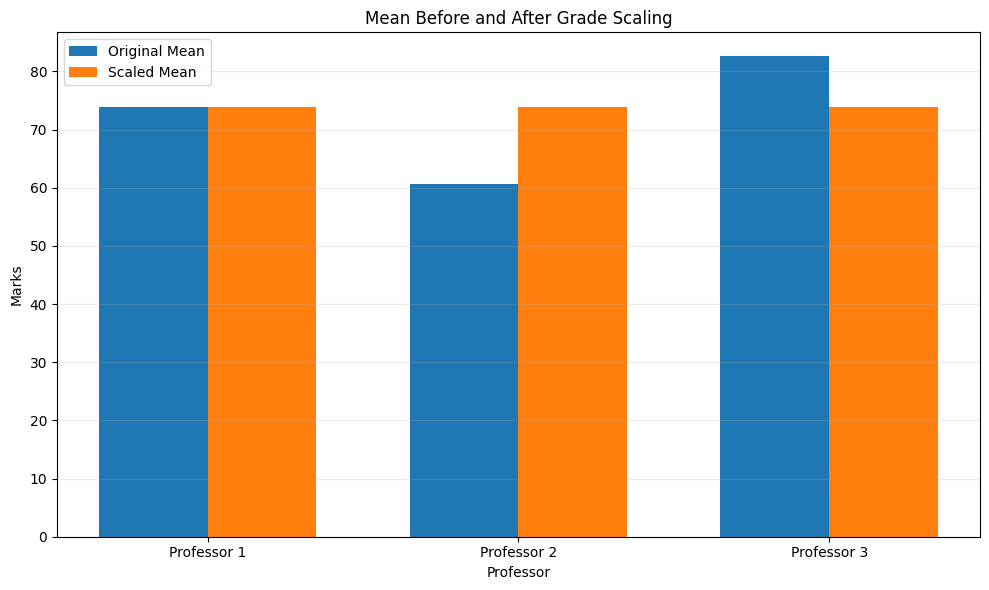

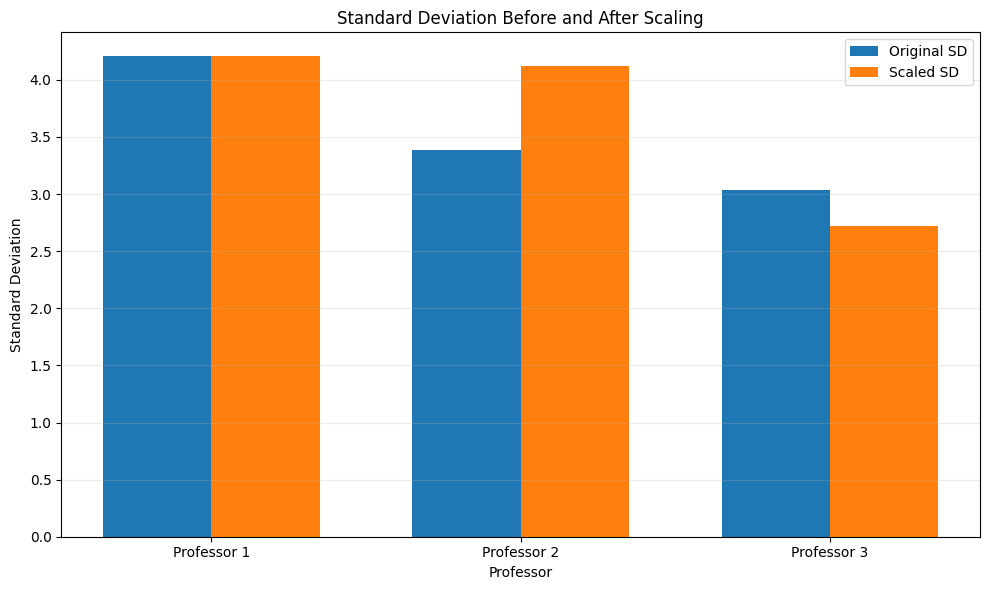

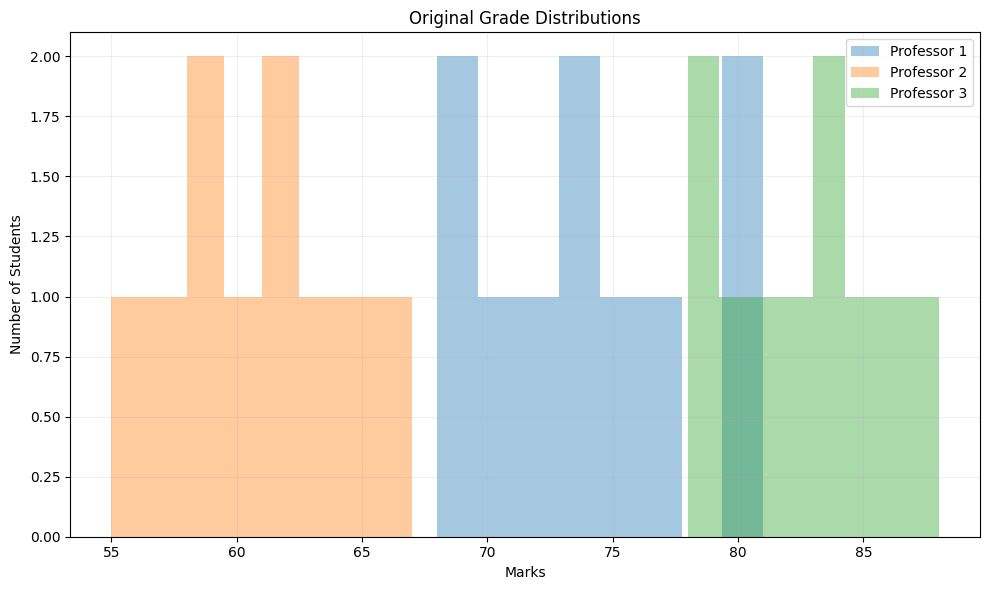

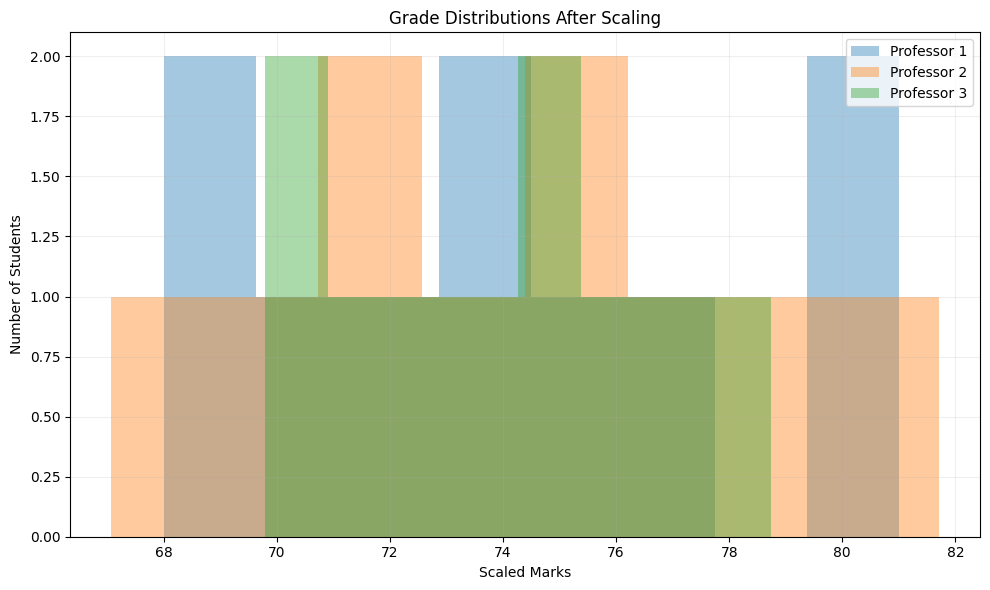



BENCHMARK TEST
Professor 1    Mean = 74.00   SD = 2.83
Professor 2    Mean = 60.00   SD = 7.07
Professor 3    Mean = 70.00   SD = 7.07


GAUSS ELIMINATION
-----------------------------------------------------------------

Initial Augmented Matrix:
[[  1.   0.   0.   1.]
 [ 74. -60.   0.   0.]
 [ 74.   0. -70.   0.]]

After Step 1:
[[ 74.     -60.       0.       0.    ]
 [  0.       0.8108   0.       1.    ]
 [  0.      60.     -70.       0.    ]]

After Step 2:
[[ 74.     -60.       0.       0.    ]
 [  0.      60.     -70.       0.    ]
 [  0.       0.       0.9459   1.    ]]

After Step 3:
[[ 74.     -60.       0.       0.    ]
 [  0.      60.     -70.       0.    ]
 [  0.       0.       0.9459   1.    ]]

Benchmark Scaling Factors:
s1 = 1.000000
s2 = 1.233333
s3 = 1.057143



                    PROJECT COMPLETE

Mathematical steps performed:

1. Read marks for three professors.
2. Calculate mean, variance and standard deviation.
3. Select Professor 1 as the reference.
4. Construc

In [ ]:
# ================================================================
# STUDENT GRADE CURVING SYSTEM (A8)
# B.Tech Mathematics Mini Project
# ================================================================

# ------------------------- IMPORTS ------------------------------

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt


# ------------------------- INPUT DATA ----------------------------

# Marks obtained by students taught by three different professors.
# You can replace these values with your own marks.

professor_1 = np.array([72, 68, 75, 81, 70, 77, 73, 69, 80, 74])
professor_2 = np.array([58, 62, 55, 67, 60, 64, 57, 61, 59, 63])
professor_3 = np.array([85, 78, 82, 88, 80, 84, 86, 79, 83, 81])

professors = {
    "Professor 1": professor_1,
    "Professor 2": professor_2,
    "Professor 3": professor_3
}


# ---------------------- ORIGINAL STATISTICS ----------------------

means = {}
variances = {}
std_devs = {}

for name, marks in professors.items():
    means[name] = np.mean(marks)
    variances[name] = np.var(marks)
    std_devs[name] = np.std(marks)

print("=" * 65)
print("             STUDENT GRADE CURVING SYSTEM")
print("=" * 65)

print("\nORIGINAL STATISTICS")
print("-" * 65)

for name in professors:
    print(
        f"{name:<15} "
        f"Mean = {means[name]:6.2f}   "
        f"Variance = {variances[name]:7.2f}   "
        f"SD = {std_devs[name]:6.2f}"
    )


# ---------------------- MATHEMATICAL ASSUMPTION ------------------

"""
ASSUMPTION:

Professor 1 is used as the reference professor.

We use a multiplicative scaling:

    New Mark = s × Original Mark

For a scaling factor s:

    New Mean = s × Original Mean

We want all three scaled means to be equal.

We set:

    s1 = 1

Therefore:

    μ1*s1 = μ2*s2
    μ1*s1 = μ3*s3

This gives the 3×3 system:

    [ 1     0       0 ] [s1]   [1]
    [ μ1   -μ2      0 ] [s2] = [0]
    [ μ1    0     -μ3] [s3]   [0]

NOTE:
This system normalizes the MEANS.
It does not automatically make the variances equal.
We therefore calculate variance and SD separately.
"""


# ---------------------- BUILD 3×3 SYSTEM -------------------------

mu1 = means["Professor 1"]
mu2 = means["Professor 2"]
mu3 = means["Professor 3"]

A = np.array([
    [1,     0,      0],
    [mu1,  -mu2,    0],
    [mu1,   0,    -mu3]
], dtype=float)

b = np.array([1, 0, 0], dtype=float)

print("\n\n3×3 LINEAR SYSTEM")
print("-" * 65)

print("Coefficient Matrix A:")
print(np.round(A, 4))

print("\nRight-hand-side vector b:")
print(b)

print("\nEquations:")
print("1) s1 = 1")
print(f"2) {mu1:.2f}s1 - {mu2:.2f}s2 = 0")
print(f"3) {mu1:.2f}s1 - {mu3:.2f}s3 = 0")


# ---------------------- GAUSS ELIMINATION ------------------------

def gauss_elimination(A, b):

    # Make a copy so the original matrix is not changed
    aug = np.column_stack((A.astype(float), b.astype(float)))

    n = len(b)

    print("\n\nGAUSS ELIMINATION")
    print("-" * 65)

    print("\nInitial Augmented Matrix:")
    print(np.round(aug, 4))

    # Forward elimination
    for i in range(n):

        # Find the best pivot row
        pivot_row = i + np.argmax(np.abs(aug[i:, i]))

        # Swap rows
        if pivot_row != i:
            aug[[i, pivot_row]] = aug[[pivot_row, i]]

        pivot = aug[i, i]

        if abs(pivot) < 1e-12:
            raise ValueError("Matrix is singular. No unique solution.")

        # Eliminate values below the pivot
        for j in range(i + 1, n):

            factor = aug[j, i] / pivot

            aug[j] = aug[j] - factor * aug[i]

        print(f"\nAfter Step {i + 1}:")
        print(np.round(aug, 4))

    # Back substitution
    x = np.zeros(n)

    for i in range(n - 1, -1, -1):

        x[i] = (
            aug[i, -1]
            - np.dot(aug[i, i + 1:n], x[i + 1:n])
        ) / aug[i, i]

    return x


# Solve the system
scaling_factors = gauss_elimination(A, b)


# ---------------------- DISPLAY SOLUTION -------------------------

print("\n\nSCALING FACTORS")
print("-" * 65)

for i, factor in enumerate(scaling_factors, start=1):
    print(f"Professor {i}:  s{i} = {factor:.6f}")


# ---------------------- NUMPY CHECK ------------------------------

numpy_solution = np.linalg.solve(A, b)

print("\nNUMPY VERIFICATION")
print("-" * 65)

print("Gauss Elimination:", np.round(scaling_factors, 6))
print("NumPy Solution:   ", np.round(numpy_solution, 6))

error = np.max(np.abs(scaling_factors - numpy_solution))

print(f"\nMaximum error = {error:.12f}")


# ---------------------- SYMPY CHECK ------------------------------

sympy_A = sp.Matrix(A)
sympy_b = sp.Matrix(b)

sympy_solution = sympy_A.LUsolve(sympy_b)

print("\nSYMPY VERIFICATION")
print("-" * 65)

print("SymPy solution:")
sp.pprint(sympy_solution)


# ---------------------- APPLY SCALING ----------------------------

scaled_data = {}

for i, (name, marks) in enumerate(professors.items()):

    scaled_data[name] = marks * scaling_factors[i]


# ---------------------- FINAL STATISTICS -------------------------

print("\n\nFINAL RESULTS")
print("-" * 105)

print(
    f"{'Professor':<15}"
    f"{'Original Mean':>16}"
    f"{'Scaled Mean':>15}"
    f"{'Original SD':>15}"
    f"{'Scaled SD':>15}"
    f"{'Original Var':>17}"
    f"{'Scaled Var':>15}"
)

print("-" * 105)

for name in professors:

    original = professors[name]
    scaled = scaled_data[name]

    print(
        f"{name:<15}"
        f"{np.mean(original):>16.2f}"
        f"{np.mean(scaled):>15.2f}"
        f"{np.std(original):>15.2f}"
        f"{np.std(scaled):>15.2f}"
        f"{np.var(original):>17.2f}"
        f"{np.var(scaled):>15.2f}"
    )


# ---------------------- CHECK NORMALIZATION ---------------------

scaled_means = [
    np.mean(scaled_data[name])
    for name in professors
]

scaled_sds = [
    np.std(scaled_data[name])
    for name in professors
]

mean_difference = max(scaled_means) - min(scaled_means)
sd_difference = max(scaled_sds) - min(scaled_sds)

print("\n\nNORMALIZATION CHECK")
print("-" * 65)

print(f"Difference between largest and smallest scaled mean = "
      f"{mean_difference:.10f}")

print(f"Difference between largest and smallest scaled SD   = "
      f"{sd_difference:.4f}")

if mean_difference < 1e-8:
    print("\n✓ SUCCESS: All three means are normalized.")
else:
    print("\n✗ Mean normalization failed.")


print(
    "\nNote: The scaling method guarantees equal means, "
    "but not equal variances."
)


# ================================================================
#                         VISUALIZATION
# ================================================================

names = list(professors.keys())

original_means = [
    np.mean(professors[name]) for name in names
]

final_means = [
    np.mean(scaled_data[name]) for name in names
]

original_sds = [
    np.std(professors[name]) for name in names
]

final_sds = [
    np.std(scaled_data[name]) for name in names
]


# ---------------------- CHART 1: MEANS ---------------------------

x = np.arange(len(names))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    original_means,
    width,
    label="Original Mean"
)

plt.bar(
    x + width / 2,
    final_means,
    width,
    label="Scaled Mean"
)

plt.xticks(x, names)
plt.ylabel("Marks")
plt.xlabel("Professor")
plt.title("Mean Before and After Grade Scaling")
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


# ---------------------- CHART 2: SD ------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    original_sds,
    width,
    label="Original SD"
)

plt.bar(
    x + width / 2,
    final_sds,
    width,
    label="Scaled SD"
)

plt.xticks(x, names)
plt.ylabel("Standard Deviation")
plt.xlabel("Professor")
plt.title("Standard Deviation Before and After Scaling")
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


# ---------------------- CHART 3: ORIGINAL DISTRIBUTION -----------

plt.figure(figsize=(10, 6))

for name in names:
    plt.hist(
        professors[name],
        bins=8,
        alpha=0.4,
        label=name
    )

plt.xlabel("Marks")
plt.ylabel("Number of Students")
plt.title("Original Grade Distributions")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ---------------------- CHART 4: SCALED DISTRIBUTION -------------

plt.figure(figsize=(10, 6))

for name in names:
    plt.hist(
        scaled_data[name],
        bins=8,
        alpha=0.4,
        label=name
    )

plt.xlabel("Scaled Marks")
plt.ylabel("Number of Students")
plt.title("Grade Distributions After Scaling")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ================================================================
#                         BENCHMARK TEST
# ================================================================

print("\n\nBENCHMARK TEST")
print("=" * 65)

benchmark = {
    "Professor 1": np.array([70, 72, 74, 76, 78]),
    "Professor 2": np.array([50, 55, 60, 65, 70]),
    "Professor 3": np.array([60, 65, 70, 75, 80])
}

for name, marks in benchmark.items():

    print(
        f"{name:<15}"
        f"Mean = {np.mean(marks):.2f}   "
        f"SD = {np.std(marks):.2f}"
    )


# Benchmark means
bm1 = np.mean(benchmark["Professor 1"])
bm2 = np.mean(benchmark["Professor 2"])
bm3 = np.mean(benchmark["Professor 3"])

# Benchmark 3×3 system
benchmark_A = np.array([
    [1,    0,     0],
    [bm1, -bm2,   0],
    [bm1,  0,   -bm3]
], dtype=float)

benchmark_b = np.array([1, 0, 0], dtype=float)

# Solve benchmark
benchmark_solution = gauss_elimination(
    benchmark_A,
    benchmark_b
)

print("\nBenchmark Scaling Factors:")

for i, factor in enumerate(benchmark_solution, start=1):
    print(f"s{i} = {factor:.6f}")


# ================================================================
#                         PROJECT SUMMARY
# ================================================================

print("\n\n")
print("=" * 65)
print("                    PROJECT COMPLETE")
print("=" * 65)

print("""
Mathematical steps performed:

1. Read marks for three professors.
2. Calculate mean, variance and standard deviation.
3. Select Professor 1 as the reference.
4. Construct a 3×3 linear system.
5. Solve the system using Gaussian elimination.
6. Calculate scaling factors.
7. Scale the student marks.
8. Verify the solution using NumPy and SymPy.
9. Compare original and scaled statistics.
10. Generate mathematical visualization charts.
11. Run a benchmark dataset.

Main mathematical result:
The scaling factors make the three group means equal.

Important limitation:
A simple multiplicative scaling does not generally make
both mean AND variance equal simultaneously. Therefore,
variance is reported and analyzed separately in this version.
""")

print("=" * 65)